In [1]:
import torch
import subprocess

def check_gpu_status():
    print("--- Pengecekan via PyTorch ---")
    cuda_tersedia = torch.cuda.is_available()
    print(f"CUDA Tersedia: {cuda_tersedia}")
    
    if cuda_tersedia:
        gpu_count = torch.cuda.device_count()
        print(f"Jumlah GPU: {gpu_count}")
        for i in range(gpu_count):
            print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
            # Mengecek memori (VRAM)
            mem_total = torch.cuda.get_device_properties(i).total_memory / (1024**3)
            print(f"VRAM Total: {mem_total:.2f} GB")
    else:
        print("Peringatan: CUDA tidak terdeteksi oleh PyTorch.")

    print("\n--- Pengecekan via Sistem (nvidia-smi) ---")
    try:
        # Menjalankan perintah nvidia-smi untuk melihat status driver
        nvidia_smi = subprocess.check_output("nvidia-smi --query-gpu=name,driver_version --format=csv,noheader", shell=True)
        print(f"Driver Info: {nvidia_smi.decode('utf-8').strip()}")
    except Exception:
        print("Gagal menjalankan nvidia-smi. Pastikan driver NVIDIA sudah terinstall.")

if __name__ == "__main__":
    check_gpu_status()

--- Pengecekan via PyTorch ---
CUDA Tersedia: True
Jumlah GPU: 1
GPU 0: NVIDIA GeForce RTX 4070 Laptop GPU
VRAM Total: 7.60 GB

--- Pengecekan via Sistem (nvidia-smi) ---
Driver Info: NVIDIA GeForce RTX 4070 Laptop GPU, 590.48.01


Step 1: Install Dependencies

In [2]:
# Install libraries
!pip install -q diffusers accelerate transformers bitsandbytes xformers ftfy pandas matplotlib seaborn tensorboard
!pip install -q -U git+https://github.com/huggingface/peft.git

Step 2: Pre-processing & Captioning

In [5]:
import pandas as pd
import os

IMAGE_PATH = "/home/firania/Documents/tugasakhir/ai/images_its"
CAPTION_PATH = "/home/firania/Documents/tugasakhir/ai/caption.csv"
TRIGGER_WORD = "itstvstyle"

# Baca CSV
df = pd.read_csv(CAPTION_PATH, delimiter='|')
# Kita hajar semua 15.000 data, tapi hanya buatkan .txt jika gambarnya ada
print(f"Memproses seluruh dataset ({len(df)} baris)...")

# Map semua file di folder agar pencarian cepat
files_in_folder = os.listdir(IMAGE_PATH)
# Buat kamus: { 'nama_file_tanpa_ekstensi' : 'nama_file_lengkap_dengan_ekstensi' }
image_map = {os.path.splitext(f)[0].lower(): f for f in files_in_folder if f.lower().endswith(('.jpg', '.png', '.jpeg'))}

count_created = 0

for index, row in df.iterrows():
    img_name_csv = str(row['Image_name']).strip()
    caption = str(row['caption'])
    
    # Ambil nama tanpa ekstensi dari CSV
    base_name_csv = os.path.splitext(img_name_csv)[0].lower()
    
    # Cek apakah nama tersebut ada di folder images_its
    if base_name_csv in image_map:
        # Gunakan nama file asli dari folder untuk menentukan nama file .txt
        actual_image_name = image_map[base_name_csv]
        txt_filename = os.path.splitext(actual_image_name)[0] + ".txt"
        txt_path = os.path.join(IMAGE_PATH, txt_filename)
        
        with open(txt_path, "w", encoding='utf-8') as f:
            f.write(f"{TRIGGER_WORD}, {caption}")
        count_created += 1

print(f"✅ Berhasil membuat {count_created} file teks dari {len(df)} baris CSV.")

Memproses seluruh dataset (16452 baris)...
✅ Berhasil membuat 16452 file teks dari 16452 baris CSV.


Sel 3: Eksekusi Training

In [11]:
import os

# Pastikan kita di folder ai
os.chdir('/home/firania/Documents/tugasakhir/ai')

# Hapus file lama yang rusak/kosong jika ada
if os.path.exists("train_text_to_image_lora.py"):
    os.remove("train_text_to_image_lora.py")

# Download dari path yang benar (examples/text_to_image/...)
!wget https://raw.githubusercontent.com/huggingface/diffusers/main/examples/text_to_image/train_text_to_image_lora.py

# Verifikasi ukuran file (harus > 0 bytes)
if os.path.exists("train_text_to_image_lora.py") and os.path.getsize("train_text_to_image_lora.py") > 0:
    print("✅ File BERHASIL didownload dengan sempurna!")
else:
    print("❌ Download GAGAL. Cek koneksi atau coba buka URL-nya di browser.")

--2026-03-25 16:01:19--  https://raw.githubusercontent.com/huggingface/diffusers/main/examples/text_to_image/train_text_to_image_lora.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 43234 (42K) [text/plain]
Saving to: ‘train_text_to_image_lora.py’

train_text_to_image 100%[===================>]  42.22K  --.-KB/s    in 0.03s   

2026-03-25 16:01:20 (1.29 MB/s) - ‘train_text_to_image_lora.py’ saved [43234/43234]

✅ File BERHASIL didownload dengan sempurna!


In [4]:
!pip install datasets peft modelcards

In [8]:
!pip install huggingface_hub torchvision
!pip install git+https://github.com/huggingface/diffusers

  Cloning https://github.com/huggingface/diffusers to /tmp/pip-req-build-rqaia4pc
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers /tmp/pip-req-build-rqaia4pc
  Resolved https://github.com/huggingface/diffusers to commit e358ddcce67396dd7e21146f7746bc1503699684
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.38.0.dev0-py3-none-any.whl size=5085968 sha256=c19bd911834c75fd107cc2ea842d254459f6fc9736c3a15a0057796edd526837
  Stored in directory: /tmp/pip-ephem-wheel-cache-0bxmv9_8/wheels/f7/7d/99/d361489e5762e3464b3811bc629e94cf5bf5ef44dd5c3c4d52
Successfully built diffusers
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.37.0
    Uninstalling diffusers-0.37.0:
      Successfully uninstalled diffusers-0.37.0


In [6]:
# Download versi yang cocok dengan diffusers 0.37.0
!wget https://raw.githubusercontent.com/huggingface/diffusers/v0.37.0/examples/text_to_image/train_text_to_image_lora.py

--2026-03-25 16:10:50--  https://raw.githubusercontent.com/huggingface/diffusers/v0.37.0/examples/text_to_image/train_text_to_image_lora.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 43229 (42K) [text/plain]
Saving to: ‘train_text_to_image_lora.py.1’

train_text_to_image 100%[===================>]  42.22K  --.-KB/s    in 0.03s   

2026-03-25 16:10:50 (1.41 MB/s) - ‘train_text_to_image_lora.py.1’ saved [43229/43229]



In [1]:
!pip install tensorboard

In [2]:
import os
from huggingface_hub import login
from dotenv import load_dotenv

# 1. Muat token dari file config.env
# Sesuaikan path jika file berada di lokasi berbeda
config_path = "/home/firania/Documents/tugasakhir/config.env"

if os.path.exists(config_path):
    load_dotenv(config_path)
    hf_token = os.getenv("HF_TOKEN")
    
    if hf_token:
        # 2. Lakukan login menggunakan library Python
        login(token=hf_token)
        
        # 3. Set environment variable agar dikenali oleh 'accelerate'
        os.environ["HF_TOKEN"] = hf_token
        print("✅ Autentikasi berhasil dan token telah disuntikkan ke environment.")
    else:
        print("❌ HF_TOKEN tidak ditemukan di dalam file config.env.")
else:
    print(f"❌ File tidak ditemukan di path: {config_path}")

    for index, row in df_subset.iterrows():
        img_name = str(row['Image_name'])
        caption = str(row['caption'])
    
    # Cek apakah file gambar benar-benar ada di folder
    if os.path.exists(os.path.join(IMAGE_PATH, img_name)):
        full_caption = f"{TRIGGER_WORD}, {caption}"
        base_name = os.path.splitext(img_name)[0]
        txt_path = os.path.join(IMAGE_PATH, f"{base_name}.txt")
        
        with open(txt_path, "w", encoding='utf-8') as f:
            f.write(full_caption)
    else:
        print(f"⚠️ Gambar tidak ditemukan: {img_name}")

/home/firania/anaconda3/envs/agas_skripsi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✅ Autentikasi berhasil dan token telah disuntikkan ke environment.


In [6]:
import os
files = os.listdir("/home/firania/Documents/tugasakhir/ai/images_its")
txt_files = [f for f in files if f.endswith(".txt")]
img_files = [f for f in files if f.endswith(".jpg") or f.endswith(".png")]
print(f"Jumlah Gambar: {len(img_files)}")
print(f"Jumlah Teks: {len(txt_files)}")

Jumlah Gambar: 3002
Jumlah Teks: 3001


In [7]:
!pip install -U "huggingface_hub"

In [1]:
import pandas as pd
import os
import json

# --- SET PATH ---
IMAGE_PATH = "/home/firania/Documents/tugasakhir/ai/images_its"
CAPTION_PATH = "/home/firania/Documents/tugasakhir/ai/caption.csv"
TRIGGER_WORD = "itstvstyle"

# Load Dataset
df = pd.read_csv(CAPTION_PATH, delimiter='|')
# Ambil data yang gambarnya memang ada di folder (biar tidak error)
existing_images = set(os.listdir(IMAGE_PATH))

metadata = []
print(f"Memproses metadata untuk folder {IMAGE_PATH}...")

for index, row in df.iterrows():
    img_name = str(row['Image_name']).strip()
    caption = str(row['caption']).strip()
    
    if img_name in existing_images:
        # Format JSONL yang diminta Hugging Face
        metadata.append({
            "file_name": img_name,
            "text": f"{TRIGGER_WORD}, {caption}"
        })

# Simpan sebagai metadata.jsonl di DALAM folder images_its
jsonl_path = os.path.join(IMAGE_PATH, "metadata.jsonl")
with open(jsonl_path, 'w', encoding='utf-8') as f:
    for entry in metadata:
        f.write(json.dumps(entry) + "\n")

print(f"✅ Selesai! File {jsonl_path} berhasil dibuat dengan {len(metadata)} entri.")

Memproses metadata untuk folder /home/firania/Documents/tugasakhir/ai/images_its...
✅ Selesai! File /home/firania/Documents/tugasakhir/ai/images_its/metadata.jsonl berhasil dibuat dengan 16452 entri.


In [3]:
!accelerate launch \
  --num_processes=1 \
  --num_machines=1 \
  --mixed_precision="fp16" \
  --dynamo_backend="no" \
  train_text_to_image_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --train_data_dir="/home/firania/Documents/tugasakhir/ai/images_its" \
  --caption_column="text" \
  --resolution=512 \
  --center_crop \
  --random_flip \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --max_train_steps=5000 \
  --learning_rate=1e-04 \
  --max_grad_norm=1 \
  --lr_scheduler="cosine" \
  --lr_warmup_steps=0 \
  --output_dir="/home/firania/Documents/tugasakhir/temp_lora_output" \
  --report_to="tensorboard" \
  --mixed_precision="fp16" \
  --rank=128 \
  --seed=42

03/25/2026 17:12:29 - INFO - __main__ - [RANK 0] Distributed environment: NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

/home/firania/anaconda3/envs/agas_skripsi/lib/python3.10/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
03/25/2026 17:12:30 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/runwayml/stable-diffusion-v1-5/resolve/main/scheduler/scheduler_config.json "HTTP/1.1 307 Temporary Redirect"
03/25/2026 17:12:30 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5/resolve/main/scheduler/scheduler_config.json "HTTP/1.1 307 Temporary Redirect"
03/25/2026 17:12:30 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/stable-diffusion-v1-5/stable-diffusi

In [4]:
import shutil
import os

# Path sumber hasil training
SOURCE_LORA = "/home/firania/Documents/tugasakhir/temp_lora_output/pytorch_lora_weights.safetensors"
# Path tujuan di backend
BACKEND_LORA_DIR = "/home/firania/Documents/tugasakhir/backend/models/lora"

os.makedirs(BACKEND_LORA_DIR, exist_ok=True)

# Hitung versi untuk penamaan file
existing_files = [f for f in os.listdir(BACKEND_LORA_DIR) if f.startswith("itstv_style_v")]
version = len(existing_files) + 1
final_name = f"itstv_style_v{version}.safetensors"

# Copy ke versi spesifik dan versi default (itstv_style.safetensors)
shutil.copy(SOURCE_LORA, os.path.join(BACKEND_LORA_DIR, final_name))
shutil.copy(SOURCE_LORA, os.path.join(BACKEND_LORA_DIR, "itstv_style.safetensors"))

print(f"✅ Model diamankan sebagai: {final_name}")
print(f"🚀 Model default di backend telah diperbarui!")

✅ Model diamankan sebagai: itstv_style_v1.safetensors
🚀 Model default di backend telah diperbarui!


In [5]:
import torch
from diffusers import StableDiffusionPipeline

# 1. Load Base Model
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16).to("cuda")

# 2. Load LoRA yang BARU SAJA jadi
lora_path = "/home/firania/Documents/tugasakhir/backend/models/lora/itstv_style.safetensors"
pipe.load_lora_weights(lora_path)

# 3. Masukkan Prompt (Wajib pakai trigger word 'itstvstyle')
prompt = "itstvstyle, a high quality cinematic shot of a student presenting in front of ITS Surabaya Rectorate building, golden hour lighting"
negative_prompt = "low quality, blurry, distorted face, messy room"

print("Sedang merender hasil karya AI kamu...")
image = pipe(prompt, negative_prompt=negative_prompt, num_inference_steps=30, guidance_scale=7.5).images[0]

# 4. Simpan & Tampilkan
image.save("hasil_perdana_itstv.png")
image.show()
print("✅ Cek file 'hasil_perdana_itstv.png' untuk melihat hasilnya!")

/home/firania/anaconda3/envs/agas_skripsi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 816.56it/s]s]
CLIPTextModel LOAD REPORT from: /home/firania/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 396/396 [00:00<00:00, 2664.47it/s]2.57it/s]
StableDiffusionSafetyChecker LOAD REPORT from: /home/firania/.cache/huggingface/hub/models--runwayml--stable-diffusion-v

Sedang merender hasil karya AI kamu...


100%|██████████| 30/30 [00:02<00:00, 10.18it/s]


✅ Cek file 'hasil_perdana_itstv.png' untuk melihat hasilnya!


Step 4: Visualisasi Grafik Loss FUnction

✅ File log ditemukan di: /home/firania/Documents/tugasakhir/temp_lora_output/logs/text2image-fine-tune/events.out.tfevents.1774433561.firania-Katana-15-B13VGK.21615.0
Tags yang ditemukan: ['train_loss']


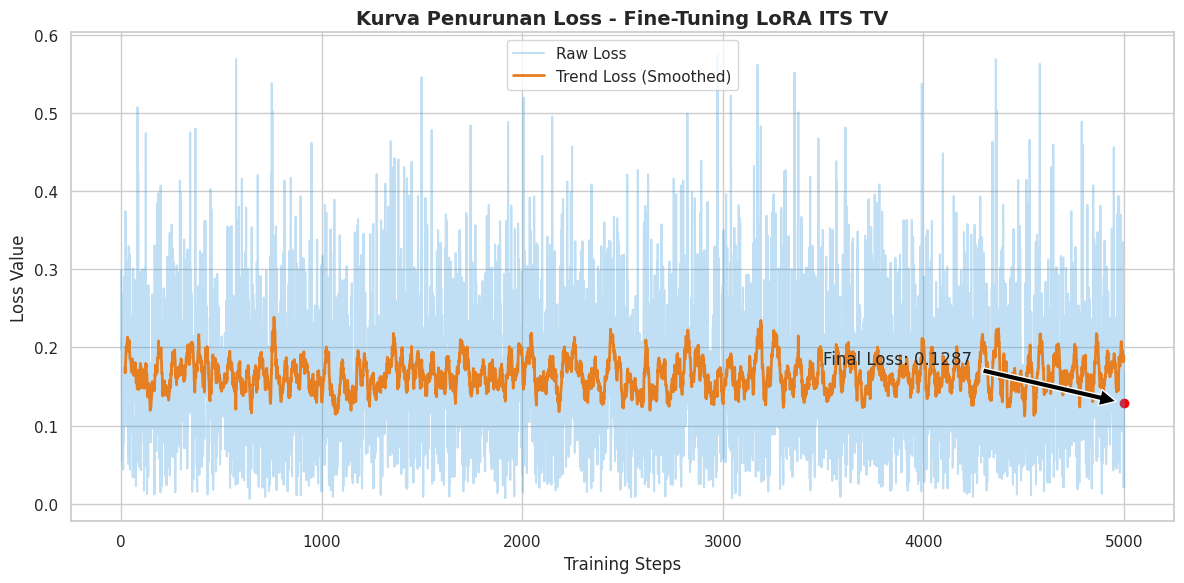

📊 Grafik sukses disimpan di: /home/firania/Documents/tugasakhir/ai/training_loss_v1.png


In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorboard.backend.event_processing import event_accumulator

def find_tfevents_file(path):
    """Mencari file event tensorboard secara rekursif"""
    for root, dirs, files in os.walk(path):
        for file in files:
            if "events.out.tfevents" in file:
                return os.path.join(root, file)
    return None

# --- KONFIGURASI ---
BASE_LOG_DIR = "/home/firania/Documents/tugasakhir/temp_lora_output"
SAVE_GRAPH_PATH = "/home/firania/Documents/tugasakhir/ai/training_loss_v1.png"

# Cari file log secara otomatis
event_file = find_tfevents_file(BASE_LOG_DIR)

if event_file:
    print(f"✅ File log ditemukan di: {event_file}")
    ea = event_accumulator.EventAccumulator(event_file)
    ea.Reload()
    
    # Ambil semua tag yang tersedia
    available_tags = ea.Tags()['scalars']
    print(f"Tags yang ditemukan: {available_tags}")
    
    # Cari tag yang mengandung kata 'loss'
    loss_tag = next((tag for tag in available_tags if 'loss' in tag.lower()), None)
    
    if loss_tag:
        events = ea.Scalars(loss_tag)
        steps = [e.step for e in events]
        values = [e.value for e in events]
        
        # Plotting
        plt.figure(figsize=(12, 6))
        sns.set_theme(style="whitegrid")
        
        df = pd.DataFrame({'steps': steps, 'loss': values})
        # Smoothing untuk estetika Bab 4
        df['loss_smooth'] = df['loss'].rolling(window=min(20, len(df))).mean()
        
        plt.plot(df['steps'], df['loss'], alpha=0.3, color='#3498db', label='Raw Loss')
        plt.plot(df['steps'], df['loss_smooth'], color='#e67e22', linewidth=2, label='Trend Loss (Smoothed)')
        
        plt.title('Kurva Penurunan Loss - Fine-Tuning LoRA ITS TV', fontsize=14, fontweight='bold')
        plt.xlabel('Training Steps', fontsize=12)
        plt.ylabel('Loss Value', fontsize=12)
        plt.legend()
        
        # Beri tanda di titik akhir
        final_loss = values[-1]
        plt.scatter(steps[-1], final_loss, color='red')
        plt.annotate(f'Final Loss: {final_loss:.4f}', 
                     xy=(steps[-1], final_loss), 
                     xytext=(steps[-1]*0.7, final_loss+0.05),
                     arrowprops=dict(facecolor='black', shrink=0.05))

        plt.tight_layout()
        plt.savefig(SAVE_GRAPH_PATH, dpi=300)
        plt.show()
        print(f"📊 Grafik sukses disimpan di: {SAVE_GRAPH_PATH}")
    else:
        print("❌ File log ada, tapi tidak ada data 'loss' di dalamnya.")
else:
    print(f"❌ Tidak ditemukan file events.out.tfevents di {BASE_LOG_DIR}")

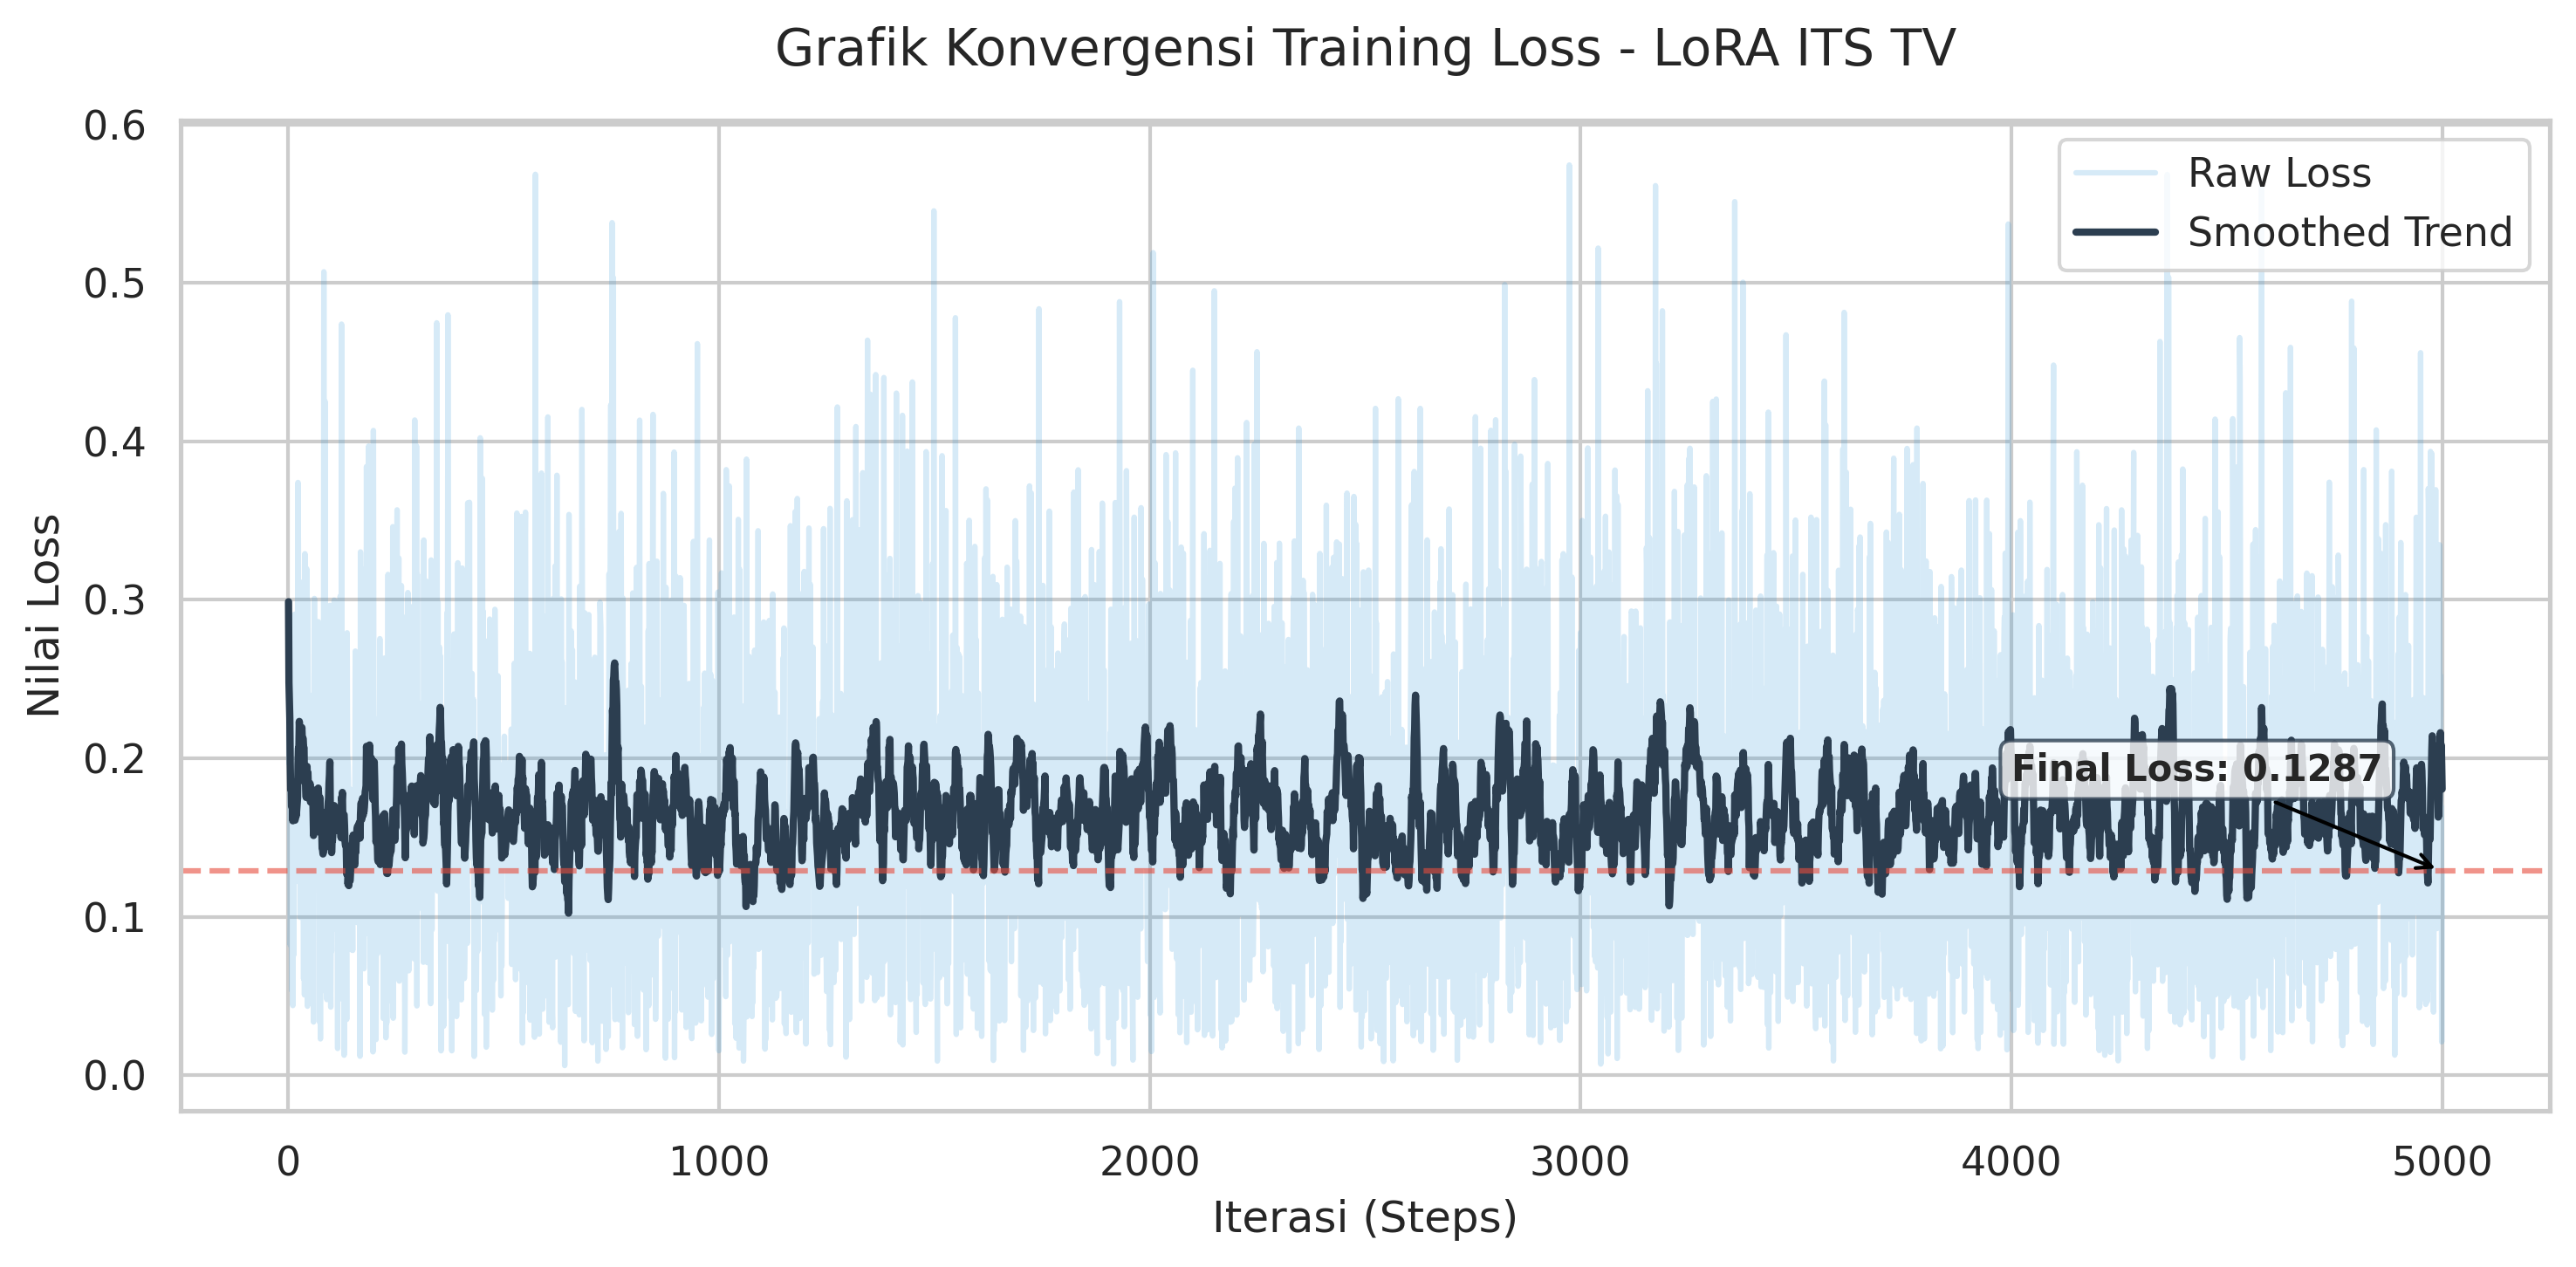

✅ Grafik 'Clean' berhasil disimpan di: /home/firania/Documents/tugasakhir/ai/training_loss_clean.png


In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorboard.backend.event_processing import event_accumulator

def get_clean_loss_data(log_dir):
    # 1. Cari file tfevents secara mendalam
    event_file = None
    for root, dirs, files in os.walk(log_dir):
        for file in files:
            if "events.out.tfevents" in file:
                event_file = os.path.join(root, file)
                break
        if event_file: break
            
    if not event_file:
        return None, None

    # 2. Ekstrak data
    ea = event_accumulator.EventAccumulator(event_file)
    ea.Reload()
    
    tags = ea.Tags()['scalars']
    # Cari tag yang paling mungkin adalah loss (biasanya 'train/loss' atau 'loss')
    loss_tag = next((t for t in tags if 'loss' in t.lower()), None)
    
    if not loss_tag:
        return None, None

    events = ea.Scalars(loss_tag)
    return [e.step for e in events], [e.value for e in events]

# --- CONFIG ---
LOG_DIR = "/home/firania/Documents/tugasakhir/temp_lora_output"
SAVE_PATH = "/home/firania/Documents/tugasakhir/ai/training_loss_clean.png"

steps, loss = get_clean_loss_data(LOG_DIR)

if steps:
    # Set gaya visual profesional
    sns.set_theme(style="whitegrid", font="sans-serif")
    plt.figure(figsize=(10, 5), dpi=300) # Resolusi tinggi untuk cetak skripsi
    
    # Hitung Smoothing (Moving Average)
    df = pd.DataFrame({'step': steps, 'loss': loss})
    df['smooth'] = df['loss'].rolling(window=15, min_periods=1).mean()
    
    # Plot Data Mentah (Transparan/Tipis)
    plt.plot(df['step'], df['loss'], color='#3498db', alpha=0.2, label='Raw Loss')
    
    # Plot Data Halus (Garis Utama)
    plt.plot(df['step'], df['smooth'], color='#2c3e50', linewidth=2, label='Smoothed Trend')
    
    # Tambahkan Garis Horizontal di Final Loss
    final_loss = loss[-1]
    plt.axhline(y=final_loss, color='#e74c3c', linestyle='--', alpha=0.6)
    
    # Anotasi Titik Akhir
    plt.annotate(f'Final Loss: {final_loss:.4f}', 
                 xy=(steps[-1], final_loss), 
                 xytext=(steps[-1]*0.8, final_loss + (max(loss)*0.1)),
                 arrowprops=dict(arrowstyle='->', color='black', lw=1),
                 fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#2c3e50", alpha=0.8))

    # Judul dan Label (Format Skripsi)
    plt.title('Grafik Konvergensi Training Loss - LoRA ITS TV', fontsize=14, pad=15)
    plt.xlabel('Iterasi (Steps)', fontsize=12)
    plt.ylabel('Nilai Loss', fontsize=12)
    plt.legend(frameon=True, loc='upper right')
    
    # Optimasi Tampilan
    plt.tight_layout()
    plt.savefig(SAVE_PATH)
    plt.show()
    print(f"✅ Grafik 'Clean' berhasil disimpan di: {SAVE_PATH}")
else:
    print("❌ Data tidak ditemukan. Pastikan proses training tadi menghasilkan file log.")

In [9]:
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

def calculate_clip_score(image_path, text):
    # Menggunakan model CLIP standar industri dari OpenAI
    model_id = "openai/clip-vit-base-patch32"
    model = CLIPModel.from_pretrained(model_id)
    processor = CLIPProcessor.from_pretrained(model_id)

    # Load dan preprocess gambar + teks
    image = Image.open(image_path)
    inputs = processor(text=[text], images=image, return_tensors="pt", padding=True)

    # Ekstraksi fitur (embedding)
    with torch.no_grad():
        image_embeds = model.get_image_features(inputs['pixel_values'])
        text_embeds = model.get_text_features(inputs['input_ids'])

    # Normalisasi vektor
    image_embeds = image_embeds / image_embeds.norm(p=2, dim=-1, keepdim=True)
    text_embeds = text_embeds / text_embeds.norm(p=2, dim=-1, keepdim=True)

    # Hitung Cosine Similarity (CLIP Score)
    cosine_sim = torch.matmul(image_embeds, text_embeds.t())
    return cosine_sim.item()

# --- TESTING ---
img_path = "/home/firania/Documents/tugasakhir/ai/hasil_perdana_itstv.png" # Ganti dengan path gambarmu
prompt_text = "itstvstyle, a high quality cinematic shot of a student presenting in front of ITS Surabaya Rectorate building, golden hour lighting"

score = calculate_clip_score(img_path, prompt_text)
print(f"🚀 CLIP Score (Cosine Similarity): {score:.4f}")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 46338.18it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


AttributeError: 'BaseModelOutputWithPooling' object has no attribute 'norm'

Step 5: Auto-Versioning Model Saver

In [8]:
import shutil

BASE_MODEL_SAVE_DIR = "/home/firania/Documents/tugasakhir/backend/models/lora"
os.makedirs(BASE_MODEL_SAVE_DIR, exist_ok=True)

# Hitung jumlah file yang sudah ada untuk menentukan versi
existing_versions = [f for f in os.listdir(BASE_MODEL_SAVE_DIR) if f.endswith('.safetensors')]
version_num = len(existing_versions) + 1

# Path akhir
final_filename = f"itstv_style_v{version_num}.safetensors"
FINAL_SAVE_PATH = os.path.join(BASE_MODEL_SAVE_DIR, final_filename)

# Copy file dari output training ke folder backend
source_file = "temp_lora_output/pytorch_lora_weights.safetensors"

if os.path.exists(source_file):
    shutil.copy(source_file, FINAL_SAVE_PATH)
    # Buat copy cadangan sebagai 'itstv_style.safetensors' (untuk dibaca default oleh backend)
    shutil.copy(source_file, os.path.join(BASE_MODEL_SAVE_DIR, "itstv_style.safetensors"))
    print(f"✅ Model berhasil disimpan sebagai: {final_filename}")
    print(f"✅ Model default 'itstv_style.safetensors' diperbarui.")
else:
    print("❌ Error: File pytorch_lora_weights.safetensors tidak ditemukan!")

❌ Error: File pytorch_lora_weights.safetensors tidak ditemukan!
